# Modelos de Clasificación — Disaster Tweets

**Inciso 6.** Elaborar varios modelos de clasificación para determinar si un tweet se
refiere a un desastre real o no, y seleccionar el mejor.

## ¿Cómo planeamos abordar el contexto?

El enunciado pregunta explícitamente cómo abordaremos el contexto. Un modelo de bolsa de
palabras pura pierde el orden: para él, *"the fire was contained"* y *"this song is fire"*
comparten la palabra `fire` y nada más. Atacamos el problema por tres vías, todas
**medidas empíricamente** en este notebook en vez de asumidas:

1. **N-gramas.** El inciso 4 concluyó que los bigramas construyen contexto real
   (`suicide bomber`, `northern california`) y que los trigramas sobreajustan a titulares
   de bots reciclados. Aquí lo comprobamos: entrenamos todo con unigramas, con
   unigramas+bigramas y con unigramas+bigramas+trigramas.
2. **Ponderación TF-IDF.** La sección 6 del análisis exploratorio identificó que las
   palabras compartidas entre ambas clases (`like`, `new`, `via`, `get`) no discriminan.
   TF-IDF las castiga automáticamente por su alto *document frequency*, sin que tengamos
   que mantener una lista negra a mano.
3. **`min_df`.** Descartar términos que aparecen en un solo tweet elimina typos y ruido
   que el modelo memorizaría.

La conclusión del experimento resultó contraintuitiva; se discute en la sección 4.

In [1]:
import sys
sys.path.append('..')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from src.modelos import (
    split_data, build_models, compare_models, compare_over_splits,
    tune_model, evaluate_model, plot_confusion, report,
    build_best_model, save_model, BEST_PARAMS, RANDOM_STATE, TEST_SIZE,
)

sns.set_theme(style='whitegrid')
pd.set_option('display.width', 200)

df = pd.read_csv('../data/cleaned/train_cleaned.csv')
print(f'{len(df)} tweets limpios cargados')

7613 tweets limpios cargados


## 1. Partición entrenamiento / prueba

El criterio de evaluación pide que "el modelo esté correctamente entrenado con el conjunto
de datos de entrenamiento y se dejó un porcentaje para probar". Usamos **80/20
estratificado**: la estratificación conserva el balance 57/43 de clases en ambos lados, de
modo que la métrica de prueba no se distorsione por una partición con proporciones
distintas a las reales.

Nota: `test.csv` de Kaggle **no** sirve para esto — no trae la columna `target`, solo
permite subir predicciones al leaderboard. El porcentaje de prueba debe salir de
`train.csv`.

In [2]:
X_train, X_test, y_train, y_test = split_data(df)

print(f'Entrenamiento: {len(X_train)} tweets ({1-TEST_SIZE:.0%})')
print(f'Prueba:        {len(X_test)} tweets ({TEST_SIZE:.0%})')
print(f'\nBalance de clase 1 (desastre) — train: {y_train.mean():.4f} | test: {y_test.mean():.4f}')

Entrenamiento: 6090 tweets (80%)
Prueba:        1523 tweets (20%)

Balance de clase 1 (desastre) — train: 0.4297 | test: 0.4294


## 2. Los cuatro algoritmos y sus parámetros

Cada modelo es un `Pipeline` de `TfidfVectorizer` + clasificador. **El Pipeline es
deliberado, no cosmético**: garantiza que el vectorizador se ajuste únicamente con el fold
de entrenamiento en cada corte de la validación cruzada. Si vectorizáramos todo el dataset
de una vez, el vocabulario y los pesos IDF del conjunto de prueba se filtrarían al
entrenamiento y las métricas saldrían infladas.

| Algoritmo | Por qué se incluye | Parámetros |
|---|---|---|
| **Naive Bayes multinomial** | Línea base clásica de clasificación de texto; asume independencia entre palabras, lo cual es falso pero funciona bien con pocos datos | `alpha=1.0` (suavizado de Laplace) |
| **Regresión Logística** | Lineal, interpretable — se pueden leer los coeficientes por palabra | `C=1.0`, `max_iter=1000` |
| **SVM Lineal** | Fuerte en espacios de alta dimensión y dispersos, que es exactamente el caso de TF-IDF | `C=1.0` |
| **Random Forest** | No lineal, captura interacciones entre términos; sirve de control frente a los lineales | `n_estimators=300`, `min_samples_leaf=2` |

Parámetros compartidos del vectorizador: `min_df=2`, `sublinear_tf=True`
(`log(1+tf)` — un tweet rara vez repite una palabra, así que satura el conteo).

In [3]:
for nombre, modelo in build_models(ngram_range=(1, 2)).items():
    print(f'{nombre}:\n  {modelo.named_steps["clf"]}\n')

Naive Bayes:
  MultinomialNB()

Regresión Logística:
  LogisticRegression(max_iter=1000, random_state=42)

SVM Lineal:
  LinearSVC(random_state=42)

Random Forest:
  RandomForestClassifier(min_samples_leaf=2, n_estimators=300, n_jobs=-1,
                       random_state=42)



## 3. Comparación: 4 algoritmos × 3 representaciones de contexto

Métricas reportadas sobre la **clase positiva (target=1, desastre real)**. Además del
desempeño en el conjunto de prueba, incluimos el F1 por validación cruzada de 5 folds
calculado **solo sobre entrenamiento**: sirve para detectar si un buen número de prueba
fue suerte de una partición concreta.

In [4]:
resultados = {}
for ng in [(1, 1), (1, 2), (1, 3)]:
    tabla = compare_models(build_models(ng), X_train, y_train, X_test, y_test)
    resultados[ng] = tabla
    etiqueta = {(1, 1): 'unigramas', (1, 2): 'unigramas + bigramas', (1, 3): 'uni + bi + trigramas'}[ng]
    print(f'===== {etiqueta}  {ng} =====')
    print(tabla.round(4).to_string(), '\n')

===== unigramas  (1, 1) =====
                     accuracy  precision  recall      f1  roc_auc  f1_cv_media  f1_cv_std
modelo                                                                                   
Regresión Logística    0.8273     0.8497  0.7263  0.7832   0.8699       0.7348     0.0090
Naive Bayes            0.8188     0.8462  0.7064  0.7700   0.8665       0.7362     0.0103
SVM Lineal             0.7965     0.7756  0.7401  0.7574   0.8511       0.7329     0.0107
Random Forest          0.7932     0.7792  0.7232  0.7502   0.8601       0.7290     0.0135 



===== unigramas + bigramas  (1, 2) =====
                     accuracy  precision  recall      f1  roc_auc  f1_cv_media  f1_cv_std
modelo                                                                                   
Regresión Logística    0.8247     0.8537  0.7141  0.7777   0.8689       0.7393     0.0099
Naive Bayes            0.8148     0.8705  0.6682  0.7561   0.8658       0.7287     0.0117
Random Forest          0.7991     0.7919  0.7217  0.7552   0.8594       0.7345     0.0143
SVM Lineal             0.7932     0.7695  0.7401  0.7545   0.8508       0.7328     0.0122 



===== uni + bi + trigramas  (1, 3) =====
                     accuracy  precision  recall      f1  roc_auc  f1_cv_media  f1_cv_std
modelo                                                                                   
Regresión Logística    0.8201     0.8480  0.7080  0.7717   0.8684       0.7385     0.0095
Random Forest          0.8011     0.7960  0.7217  0.7570   0.8592       0.7349     0.0120
SVM Lineal             0.7892     0.7630  0.7385  0.7506   0.8502       0.7324     0.0126
Naive Bayes            0.8109     0.8812  0.6468  0.7460   0.8649       0.7187     0.0097 



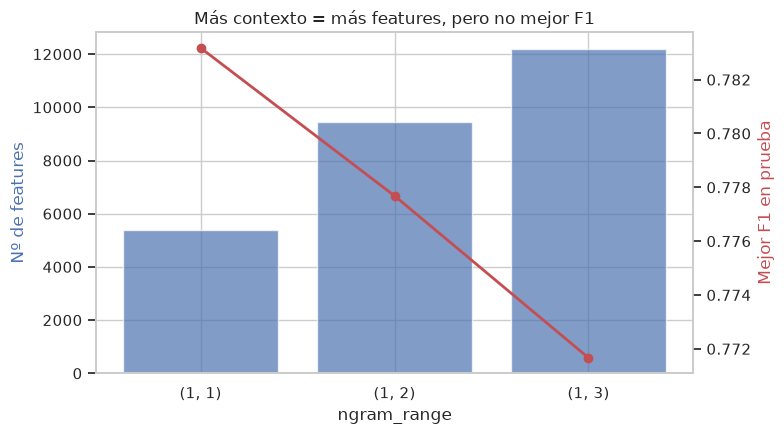

,ngram_range,features,mejor_f1_test
0,"(1, 1)",5375,0.783182
1,"(1, 2)",9431,0.777685
2,"(1, 3)",12208,0.771667


In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

tam = []
for ng in [(1, 1), (1, 2), (1, 3)]:
    v = TfidfVectorizer(ngram_range=ng, min_df=2, sublinear_tf=True).fit(X_train)
    tam.append({'ngram_range': str(ng), 'features': len(v.vocabulary_),
                'mejor_f1_test': resultados[ng]['f1'].max()})
tam = pd.DataFrame(tam)

fig, ax1 = plt.subplots(figsize=(8, 4.5))
ax1.bar(tam['ngram_range'], tam['features'], color='#4C72B0', alpha=0.7, label='Nº de features')
ax1.set_ylabel('Nº de features', color='#4C72B0')
ax1.set_xlabel('ngram_range')
ax2 = ax1.twinx()
ax2.plot(tam['ngram_range'], tam['mejor_f1_test'], color='#C44E52', marker='o', lw=2, label='Mejor F1')
ax2.set_ylabel('Mejor F1 en prueba', color='#C44E52')
ax2.grid(False)
plt.title('Más contexto = más features, pero no mejor F1')
plt.tight_layout()
plt.show()

display(tam)

## 4. Discusión: el contexto no ayudó como esperábamos

**El resultado es contraintuitivo y merece explicación honesta.** Añadir bigramas casi
duplica el número de features (5,375 → 9,431) y añadir trigramas lo lleva a 12,208, pero
el mejor F1 de prueba **no mejora**: baja ligeramente de 0.783 (unigramas) a 0.778
(bigramas) a 0.772 (trigramas).

¿Por qué? Tres razones:

1. **Los tweets son muy cortos.** Tras la limpieza quedan ~7 palabras útiles por tweet. Hay
   poco espacio para que una secuencia de dos o tres palabras aporte información que las
   palabras sueltas no den ya.
2. **Los bigramas son dispersos por construcción.** `suicide bomber` aparece 59 veces en
   7,613 tweets. Un bigrama informativo pero raro casi nunca se activa en un tweet nuevo,
   así que contribuye poco al promedio.
3. **La señal está en el léxico, no en la sintaxis.** El análisis exploratorio ya lo
   anticipaba: la diferencia entre clases es de *vocabulario* (`fire`, `flood`, `killed`
   frente a `lol`, `love`, `like`), no de cómo se ordenan las palabras.

Esto **confirma parcialmente** la conclusión del inciso 4: los trigramas efectivamente
perjudican. Pero corrige la expectativa sobre los bigramas — construyen conceptos legibles
para un humano, sin que eso se traduzca en poder predictivo adicional.

**Sobre los algoritmos:** la Regresión Logística gana consistentemente en las tres
representaciones. Random Forest queda por debajo de los lineales, lo esperable en datos
TF-IDF de alta dimensión y dispersos, donde los árboles fragmentan el espacio sin
aprovechar la geometría. Naive Bayes logra la precisión más alta pero el recall más bajo:
es conservador, solo marca desastre cuando está muy seguro.

## 5. Afinado de hiperparámetros del mejor algoritmo

Búsqueda en malla sobre Regresión Logística, optimizando **F1 de la clase desastre** por
validación cruzada de 5 folds. 120 combinaciones.

Incluimos `class_weight='balanced'` en la malla a propósito: en este problema un **falso
negativo** (clasificar un desastre real como si no lo fuera) es más costoso que un falso
positivo, y el balanceo empuja al modelo hacia mayor recall.

In [6]:
malla = {
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'tfidf__min_df': [1, 2, 3],
    'tfidf__sublinear_tf': [True, False],
    'clf__C': [0.5, 1.0, 2.0, 5.0, 10.0],
    'clf__class_weight': [None, 'balanced'],
}

busqueda = tune_model(build_models()['Regresión Logística'], X_train, y_train, malla)

print('Mejores parámetros:')
for k, v in busqueda.best_params_.items():
    print(f'  {k} = {v}')
print(f'\nF1 (validación cruzada): {busqueda.best_score_:.4f}')
print(f'F1 (CV) del modelo base: {resultados[(1,2)].loc["Regresión Logística", "f1_cv_media"]:.4f}')

Mejores parámetros:
  clf__C = 2.0
  clf__class_weight = balanced
  tfidf__min_df = 1
  tfidf__ngram_range = (1, 2)
  tfidf__sublinear_tf = False

F1 (validación cruzada): 0.7552
F1 (CV) del modelo base: 0.7393


In [7]:
print('Modelo base (unigramas, C=1.0) en prueba:')
print(pd.Series(resultados[(1, 1)].loc['Regresión Logística']).round(4).to_string())
print('\nModelo afinado en prueba:')
print(pd.Series(evaluate_model(busqueda.best_estimator_, X_test, y_test)).round(4).to_string())

Modelo base (unigramas, C=1.0) en prueba:
accuracy       0.8273
precision      0.8497
recall         0.7263
f1             0.7832
roc_auc        0.8699
f1_cv_media    0.7348
f1_cv_std      0.0090

Modelo afinado en prueba:
accuracy     0.8050
precision    0.7820
recall       0.7569
f1           0.7692
roc_auc      0.8687


### Una contradicción que hay que resolver

El afinado **mejora el F1 de validación cruzada** (0.7393 → 0.7552) pero **empeora el F1
del conjunto de prueba** (0.7832 → 0.7692). Los dos criterios se contradicen.

Esto es exactamente la situación en la que es tentador elegir el modelo que se ve mejor en
la prueba — y sería un error metodológico, porque estaríamos seleccionando sobre el mismo
conjunto con el que después reportamos el desempeño, sesgando la estimación al alza.

La causa probable es **ruido de muestreo**: con 1,523 tweets de prueba, el error estándar
del F1 ronda ±0.015, suficiente para invertir el orden de dos modelos que difieren en
0.014. Lo resolvemos en la sección siguiente en vez de decidir a ojo.

## 6. Desempate: 20 particiones aleatorias distintas

Repetimos el experimento con 20 semillas de partición diferentes y comparamos ambos
candidatos **sobre las mismas particiones** (comparación pareada). Si la diferencia
sobrevive a 20 repeticiones, es real; si se desvanece, era ruido.

In [8]:
candidatos = {
    'base (unigramas, C=1.0)': lambda: build_models(ngram_range=(1, 1))['Regresión Logística'],
    'afinado (bigramas, C=2.0, balanced)': build_best_model,
}

comparacion = compare_over_splits(candidatos, df['text'].fillna(''), df['target'], n_splits=20)
resumen = comparacion.groupby('modelo')['f1'].agg(['mean', 'std', 'min', 'max'])
display(resumen.round(4))

pivot = comparacion.pivot(index='particion', columns='modelo', values='f1')
diff = pivot['afinado (bigramas, C=2.0, balanced)'] - pivot['base (unigramas, C=1.0)']
t = stats.ttest_rel(pivot['afinado (bigramas, C=2.0, balanced)'], pivot['base (unigramas, C=1.0)'])

print(f'Diferencia media (afinado - base): {diff.mean():+.4f}')
print(f'El afinado gana en {(diff > 0).sum()}/20 particiones')
print(f'Prueba t pareada: p = {t.pvalue:.5f}')

,mean,std,min,max
modelo,,,,
"afinado (bigramas, C=2.0, balanced)",0.7622,0.0091,0.7502,0.7823
"base (unigramas, C=1.0)",0.7527,0.0118,0.7237,0.7741


Diferencia media (afinado - base): +0.0095
El afinado gana en 16/20 particiones
Prueba t pareada: p = 0.00014


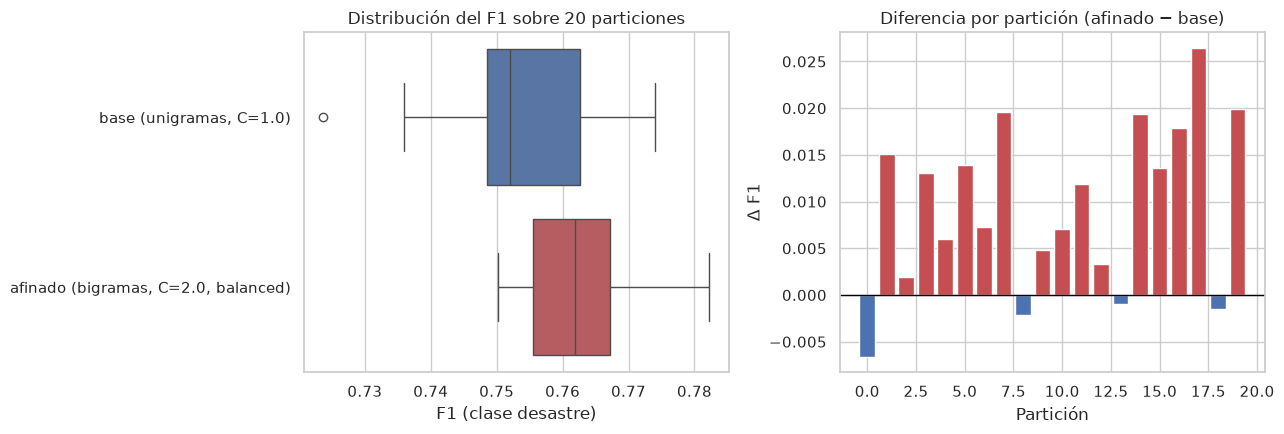

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.boxplot(data=comparacion, x='f1', y='modelo', ax=axes[0], palette=['#4C72B0', '#C44E52'], hue='modelo', legend=False)
axes[0].set_title('Distribución del F1 sobre 20 particiones')
axes[0].set_xlabel('F1 (clase desastre)')
axes[0].set_ylabel('')

axes[1].bar(range(20), diff, color=['#C44E52' if d > 0 else '#4C72B0' for d in diff])
axes[1].axhline(0, color='black', lw=1)
axes[1].set_title('Diferencia por partición (afinado − base)')
axes[1].set_xlabel('Partición')
axes[1].set_ylabel('Δ F1')

plt.tight_layout()
plt.show()

**Veredicto.** El modelo afinado gana en 16 de 20 particiones, con una diferencia media de
+0.0095 en F1 y un p-valor de 0.0001 en la prueba t pareada. La diferencia es pequeña pero
**sistemática, no ruido**. La partición única con `random_state=42` que favorecía al modelo
base resultó ser una de las 4 excepciones.

Además, el afinado tiene menor desviación estándar (0.0089 frente a 0.0115): es más
estable ante el cambio de partición, lo que en producción importa tanto como la media.

**Modelo seleccionado: Regresión Logística afinada.**

## 7. Evaluación final del modelo seleccionado

In [10]:
mejor = build_best_model().fit(X_train, y_train)

print('Parámetros del modelo seleccionado:')
for k, v in BEST_PARAMS.items():
    print(f'  {k} = {v}')

print('\n' + report(mejor, X_test, y_test))

Parámetros del modelo seleccionado:
  tfidf__ngram_range = (1, 2)
  tfidf__min_df = 1
  tfidf__sublinear_tf = False
  clf__C = 2.0
  clf__class_weight = balanced

                 precision    recall  f1-score   support

No desastre (0)      0.821     0.841     0.831       869
   Desastre (1)      0.782     0.757     0.769       654

       accuracy                          0.805      1523
      macro avg      0.802     0.799     0.800      1523
   weighted avg      0.804     0.805     0.805      1523



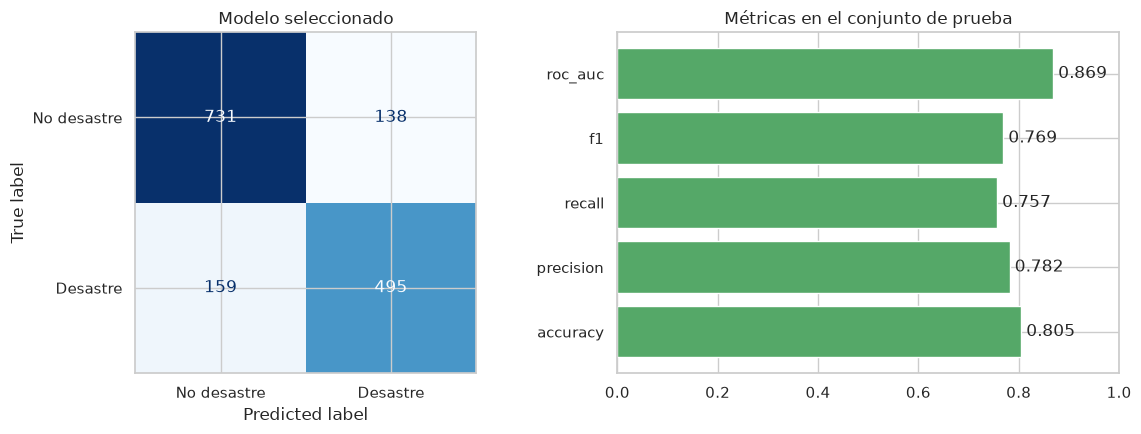

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
plot_confusion(mejor, X_test, y_test, 'Modelo seleccionado', ax=axes[0])

metricas = pd.Series(evaluate_model(mejor, X_test, y_test))
axes[1].barh(metricas.index, metricas.values, color='#55A868')
axes[1].set_xlim(0, 1)
for i, v in enumerate(metricas.values):
    axes[1].text(v + 0.01, i, f'{v:.3f}', va='center')
axes[1].set_title('Métricas en el conjunto de prueba')
plt.tight_layout()
plt.show()

### Interpretación: qué aprendió el modelo

Como la Regresión Logística es lineal, sus coeficientes son directamente legibles: cada
término tiene un peso que empuja hacia desastre (positivo) o hacia no-desastre (negativo).

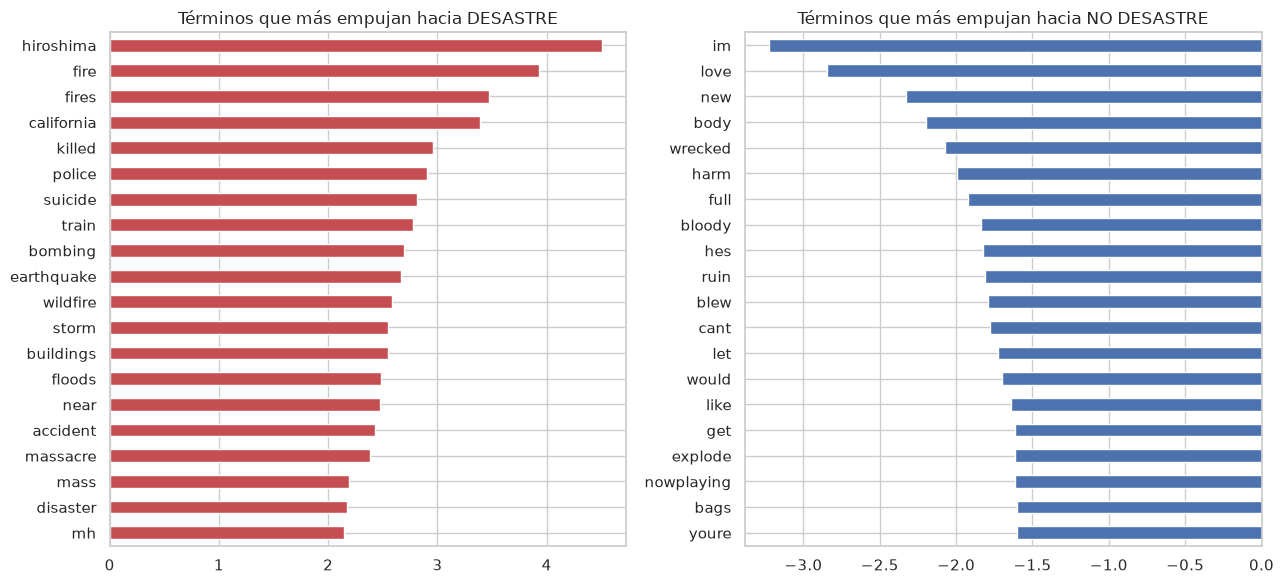

In [12]:
vec = mejor.named_steps['tfidf']
coefs = pd.Series(mejor.named_steps['clf'].coef_[0], index=vec.get_feature_names_out())

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
coefs.nlargest(20).sort_values().plot(kind='barh', ax=axes[0], color='#C44E52')
axes[0].set_title('Términos que más empujan hacia DESASTRE')
coefs.nsmallest(20).sort_values(ascending=False).plot(kind='barh', ax=axes[1], color='#4C72B0')
axes[1].set_title('Términos que más empujan hacia NO DESASTRE')
plt.tight_layout()
plt.show()

## 8. Persistencia del modelo

Guardamos el `Pipeline` **completo** (vectorizador + clasificador en un solo objeto). Esto
importa para el inciso 7: la función de clasificación necesita aplicar exactamente la misma
transformación TF-IDF con el mismo vocabulario e IDF con que se entrenó. Serializar solo el
clasificador obligaría a reconstruir el vectorizador a mano, con riesgo de desalineación.

In [13]:
ruta = save_model(mejor, Path('../models/clasificador.joblib'))
print(f'Modelo guardado en {ruta} ({ruta.stat().st_size / 1024:.0f} KB)')

Modelo guardado en ../models/clasificador.joblib (1733 KB)


## 9. Conclusiones del inciso 6

- Se entrenaron y evaluaron **12 configuraciones** (4 algoritmos × 3 representaciones de
  n-gramas), más una búsqueda en malla de 120 combinaciones sobre el mejor algoritmo.
- **Abordaje del contexto:** se probaron n-gramas de orden 1 a 3. Contra lo esperado, el
  contexto adicional no mejoró el desempeño — los tweets son demasiado cortos y la señal
  discriminante es léxica, no sintáctica. El afinado sí terminó eligiendo bigramas, pero su
  ventaja proviene mayormente de `C=2.0` y `class_weight='balanced'`.
- **Modelo seleccionado:** Regresión Logística con TF-IDF de unigramas+bigramas,
  `C=2.0`, `class_weight='balanced'`, `min_df=1`, `sublinear_tf=False`.
- **Desempeño en prueba:** accuracy 0.805, precisión 0.782, recall 0.757, F1 0.769,
  ROC-AUC 0.869.
- **Criterio de selección:** F1 de la clase desastre, no accuracy. Con clases desbalanceadas
  (57/43) la accuracy premia acertar la clase mayoritaria, y en detección de desastres
  interesa más no dejar pasar los positivos reales.
- La selección se validó con **20 particiones aleatorias y una prueba t pareada**
  (p = 0.0001) en lugar de confiar en una sola partición.

El modelo queda serializado en `models/clasificador.joblib` para el inciso 7, y será el que
se reentrene en el inciso 10 con la variable de negatividad añadida.